# Gradient Boosting Regressor — Adam Ayad

CSCK503 Machine Learning in Practice, final group project. Predicting 2019 major-road NOx emissions in Greater London.

Input: `laei2019_model_data.csv` (shared dataset from `01_data_preparation_eda.ipynb`).
Target: `NOx_total_2019`, tonnes/year per road link.
Predictors: vehicle-specific AADT flows, speed, link length, road classification. VKM and per-vehicle NOx columns are excluded as leakage.

In [1]:
import os, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

DATA_FILE = "laei2019_model_data.csv"
RANDOM_STATE = 42
TARGET = "NOx_total_2019"

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

## 1. Load data

In [2]:
df = pd.read_csv(DATA_FILE)
print(f"{df.shape[0]:,} road links, {df.shape[1]} columns")
print(f"missing values: {df.isna().sum().sum()}")
df.head(3)

66,962 road links, 25 columns
missing values: 0


,TOID,Borough,NOx_total_2019,AADT Motorcycle,AADT Taxi,AADT Petrol Car,AADT Diesel Car,AADT Electric Car,AADT Petrol PHV,AADT Diesel PHV,AADT Electric PHV,AADT Petrol LGV,AADT Diesel LGV,AADT Electric LGV,AADT 2019 - HGVs - Rigid - 2 Axles,AADT 2019 - HGVs - Rigid - 3 Axles,AADT 2019 - HGVs - Rigid - 4 or more Axles,AADT 2019 - HGVs - Articulated - 3 to 4 Axles,AADT 2019 - HGVs - Articulated - 5 Axles,AADT 2019 - HGVs - Articulated - 6 Axles,AADT 2019 - Buses,AADT 2019 - Coaches,Speed (km/hr) - Except Buses,Link Length (m),Road Classification
0,osgb4000000030337102,Bromley,0.197933,242.0,118.0,6396.0,4420.0,38.0,126.0,104.0,2.0,22.0,2510.0,6.0,95.0,14.0,30.0,6.0,13.0,36.0,324.0,197.0,13.0,54,A Road
1,osgb4000000030221346,Brent,0.294039,405.0,148.0,10718.0,7407.0,63.0,318.0,262.0,4.0,25.0,2873.0,6.0,449.0,67.0,143.0,27.0,59.0,169.0,808.0,270.0,15.0,47,A Road
2,osgb4000000030365896,Barking and Dagenham,0.237709,364.0,174.0,9468.0,6544.0,56.0,310.0,255.0,4.0,27.0,3145.0,7.0,563.0,84.0,180.0,34.0,74.0,212.0,213.0,80.0,13.0,39,A Road


## 2. Target distribution

Strongly right-skewed — median ~0.08 t/yr, max over 40. So RMSE will be driven by a few motorway links, and MAE is reported alongside it. A log target is tested later.

count    66962.0000
mean         0.1964
std          0.6377
min          0.0000
25%          0.0298
50%          0.0788
75%          0.1927
max         40.0633
Name: NOx_total_2019, dtype: float64
zero-emission links: 491


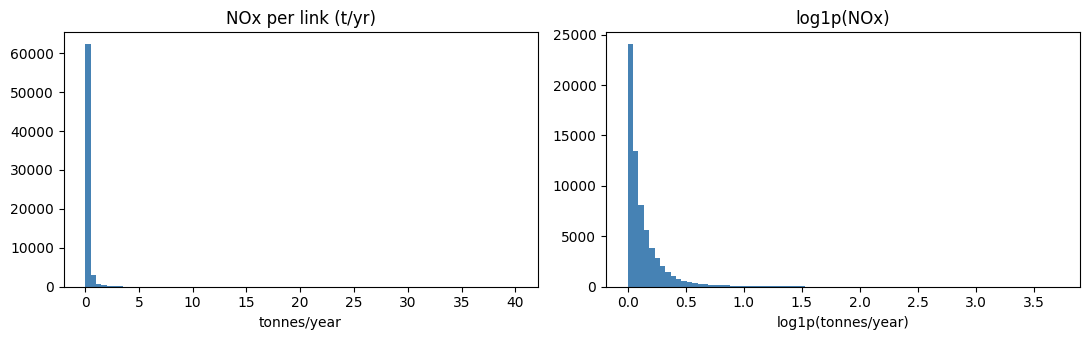

In [3]:
print(df[TARGET].describe().round(4))
print(f"zero-emission links: {(df[TARGET] == 0).sum():,}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(df[TARGET], bins=80, color="steelblue")
ax[0].set_title("NOx per link (t/yr)"); ax[0].set_xlabel("tonnes/year")
ax[1].hist(np.log1p(df[TARGET]), bins=80, color="steelblue")
ax[1].set_title("log1p(NOx)"); ax[1].set_xlabel("log1p(tonnes/year)")
plt.tight_layout(); plt.savefig("gbr_target_distribution.png", dpi=130); plt.show()

## 3. Features

Dropping `TOID` (identifier) and `Borough` (not in the shared predictor set). `Road Classification` is one-hot encoded. 80/20 split, `random_state=42` to match the other notebooks.

In [4]:
drop_cols = ["TOID", "Borough", TARGET]
X = pd.get_dummies(df.drop(columns=drop_cols), columns=["Road Classification"], dtype=int)
y = df[TARGET]
features = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"{len(features)} features | train {len(X_train):,} | test {len(X_test):,}")
features

28 features | train 53,569 | test 13,393


['AADT Motorcycle',
 'AADT Taxi',
 'AADT Petrol Car',
 'AADT Diesel Car',
 'AADT Electric Car',
 'AADT Petrol PHV',
 'AADT Diesel PHV',
 'AADT Electric PHV',
 'AADT Petrol LGV',
 'AADT Diesel LGV',
 'AADT Electric LGV',
 'AADT 2019 - HGVs - Rigid - 2 Axles',
 'AADT 2019 - HGVs - Rigid - 3 Axles',
 'AADT 2019 - HGVs - Rigid - 4 or more Axles',
 'AADT 2019 - HGVs - Articulated - 3 to 4 Axles',
 'AADT 2019 - HGVs - Articulated - 5 Axles',
 'AADT 2019 - HGVs - Articulated - 6 Axles',
 'AADT 2019 - Buses',
 'AADT 2019 - Coaches',
 'Speed (km/hr) - Except Buses',
 'Link Length (m)',
 'Road Classification_A Road',
 'Road Classification_B Road',
 'Road Classification_C / Unclassified Road',
 'Road Classification_M1',
 'Road Classification_M11',
 'Road Classification_M25',
 'Road Classification_M4']

## 4. Metrics

MAE (typical error per link), RMSE (penalises big errors), R². All on the test set, original scale, same as the other two models.

In [5]:
def evaluate(name, y_true, y_pred, fit_seconds=None):
    m = {"model": name,
         "MAE":  round(mean_absolute_error(y_true, y_pred), 4),
         "RMSE": round(mean_squared_error(y_true, y_pred) ** 0.5, 4),
         "R2":   round(r2_score(y_true, y_pred), 4)}
    if fit_seconds is not None:
        m["fit_s"] = round(fit_seconds, 1)
    return m

results = []

# same mean baseline as the regression notebook, for reference
baseline_pred = np.full(len(y_test), y_train.mean())
results.append(evaluate("Mean baseline", y_test, baseline_pred))
results[-1]

{'model': 'Mean baseline', 'MAE': 0.1867, 'RMSE': 0.4447, 'R2': -0.0013}

## 5. Baseline model

Gradient boosting fits trees in sequence, each one trained on the errors left by the previous ones. This captures non-linear effects and interactions between vehicle mix, speed and link length without specifying them up front. Defaults: 100 trees, depth 3, learning rate 0.1.

In [6]:
t0 = time.time()
gbr = GradientBoostingRegressor(random_state=RANDOM_STATE).fit(X_train, y_train)
fit_s = time.time() - t0
pred = gbr.predict(X_test)
results.append(evaluate("GBR default", y_test, pred, fit_s))
results[-1]

{'model': 'GBR default',
 'MAE': 0.0328,
 'RMSE': 0.0723,
 'R2': 0.9735,
 'fit_s': 22.5}

## 6. Log-transformed target

Fitting on `log1p(y)` and inverting with `expm1` reduces the pull of the few very large links. Metrics still on the original scale.

In [7]:
t0 = time.time()
gbr_log = GradientBoostingRegressor(random_state=RANDOM_STATE).fit(X_train, np.log1p(y_train))
fit_s = time.time() - t0
pred_log = np.expm1(gbr_log.predict(X_test))
results.append(evaluate("GBR, log target", y_test, pred_log, fit_s))
results[-1]

{'model': 'GBR, log target',
 'MAE': 0.0236,
 'RMSE': 0.077,
 'R2': 0.9699,
 'fit_s': 24.3}

## 7. Tuning

Varying `n_estimators`, `learning_rate` and `max_depth`. `subsample=0.8` fits each tree on 80% of rows, which speeds things up and regularises slightly. Small manual grid rather than a full CV search — 67k rows makes that expensive.

In [8]:
grid = [
    dict(n_estimators=100, learning_rate=0.10, max_depth=3, subsample=1.0),
    dict(n_estimators=200, learning_rate=0.10, max_depth=4, subsample=0.8),
    dict(n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.8),
    dict(n_estimators=500, learning_rate=0.05, max_depth=4, subsample=0.8),
]

fitted = {}
for params in grid:
    for log_target in (False, True):
        t0 = time.time()
        m = GradientBoostingRegressor(random_state=RANDOM_STATE, **params)
        m.fit(X_train, np.log1p(y_train) if log_target else y_train)
        fit_s = time.time() - t0
        p = np.expm1(m.predict(X_test)) if log_target else m.predict(X_test)
        label = (f"GBR{' log' if log_target else ''} n={params['n_estimators']} "
                 f"lr={params['learning_rate']} d={params['max_depth']} sub={params['subsample']}")
        r = evaluate(label, y_test, p, fit_s)
        results.append(r); fitted[label] = (m, p)
        print(r)

res_df = pd.DataFrame(results)
res_df

{'model': 'GBR n=100 lr=0.1 d=3 sub=1.0', 'MAE': 0.0328, 'RMSE': 0.0723, 'R2': 0.9735, 'fit_s': 19.9}
{'model': 'GBR log n=100 lr=0.1 d=3 sub=1.0', 'MAE': 0.0236, 'RMSE': 0.077, 'R2': 0.9699, 'fit_s': 20.1}
{'model': 'GBR n=200 lr=0.1 d=4 sub=0.8', 'MAE': 0.0185, 'RMSE': 0.0501, 'R2': 0.9873, 'fit_s': 46.1}
{'model': 'GBR log n=200 lr=0.1 d=4 sub=0.8', 'MAE': 0.0142, 'RMSE': 0.0407, 'R2': 0.9916, 'fit_s': 44.8}
{'model': 'GBR n=300 lr=0.05 d=5 sub=0.8', 'MAE': 0.0149, 'RMSE': 0.0462, 'R2': 0.9892, 'fit_s': 83.5}
{'model': 'GBR log n=300 lr=0.05 d=5 sub=0.8', 'MAE': 0.0126, 'RMSE': 0.0427, 'R2': 0.9908, 'fit_s': 84.3}
{'model': 'GBR n=500 lr=0.05 d=4 sub=0.8', 'MAE': 0.0158, 'RMSE': 0.0446, 'R2': 0.9899, 'fit_s': 112.6}
{'model': 'GBR log n=500 lr=0.05 d=4 sub=0.8', 'MAE': 0.0129, 'RMSE': 0.0435, 'R2': 0.9904, 'fit_s': 113.0}


,model,MAE,RMSE,R2,fit_s
0,Mean baseline,0.1867,0.4447,-0.0013,NaN
1,GBR default,0.0328,0.0723,0.9735,22.5
2,"GBR, log target",0.0236,0.0770,0.9699,24.3
3,GBR n=100 lr=0.1 d=3 sub=1.0,0.0328,0.0723,0.9735,19.9
4,GBR log n=100 lr=0.1 d=3 sub=1.0,0.0236,0.0770,0.9699,20.1
5,GBR n=200 lr=0.1 d=4 sub=0.8,0.0185,0.0501,0.9873,46.1
6,GBR log n=200 lr=0.1 d=4 sub=0.8,0.0142,0.0407,0.9916,44.8
7,GBR n=300 lr=0.05 d=5 sub=0.8,0.0149,0.0462,0.9892,83.5
8,GBR log n=300 lr=0.05 d=5 sub=0.8,0.0126,0.0427,0.9908,84.3
9,GBR n=500 lr=0.05 d=4 sub=0.8,0.0158,0.0446,0.9899,112.6


## 8. Model selection

MAE and RMSE disagree: the log-target models are better on the many small links but worse on the motorway links that dominate RMSE. Selecting on RMSE here, since an emissions inventory needs total tonnage right. Both are reported.

In [9]:
ranked = res_df[res_df.model.str.startswith("GBR")].sort_values("RMSE")
print(ranked.to_string(index=False))

best_label = ranked.iloc[0]["model"]
best_model, best_pred = fitted[best_label] if best_label in fitted else (gbr, pred)
print("\nselected by RMSE:", best_label)
print("best by MAE would be:", res_df[res_df.model.str.startswith("GBR")].sort_values("MAE").iloc[0]["model"])

                            model    MAE   RMSE     R2  fit_s
 GBR log n=200 lr=0.1 d=4 sub=0.8 0.0142 0.0407 0.9916   44.8
GBR log n=300 lr=0.05 d=5 sub=0.8 0.0126 0.0427 0.9908   84.3
GBR log n=500 lr=0.05 d=4 sub=0.8 0.0129 0.0435 0.9904  113.0
    GBR n=500 lr=0.05 d=4 sub=0.8 0.0158 0.0446 0.9899  112.6
    GBR n=300 lr=0.05 d=5 sub=0.8 0.0149 0.0462 0.9892   83.5
     GBR n=200 lr=0.1 d=4 sub=0.8 0.0185 0.0501 0.9873   46.1
     GBR n=100 lr=0.1 d=3 sub=1.0 0.0328 0.0723 0.9735   19.9
                      GBR default 0.0328 0.0723 0.9735   22.5
                  GBR, log target 0.0236 0.0770 0.9699   24.3
 GBR log n=100 lr=0.1 d=3 sub=1.0 0.0236 0.0770 0.9699   20.1

selected by RMSE: GBR log n=200 lr=0.1 d=4 sub=0.8
best by MAE would be: GBR log n=300 lr=0.05 d=5 sub=0.8


## 9. Diagnostics

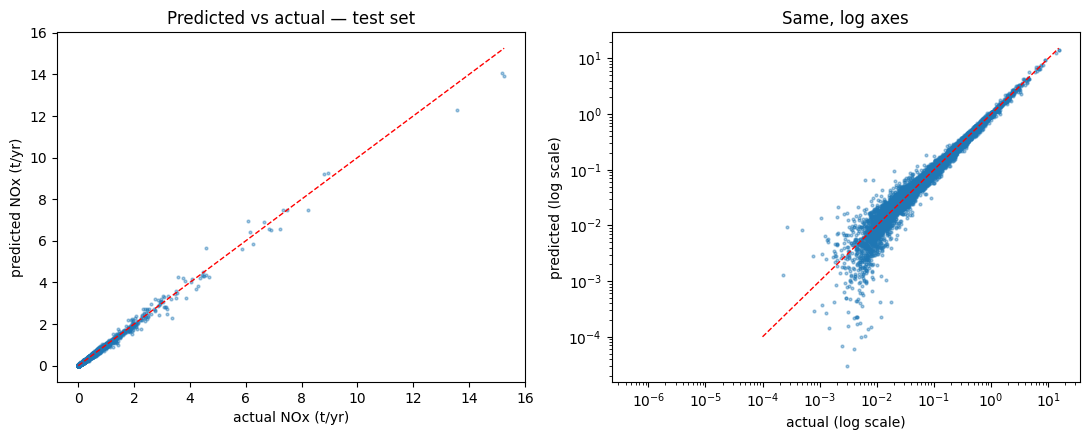

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
lim = [0, max(y_test.max(), best_pred.max())]
ax[0].scatter(y_test, best_pred, s=4, alpha=0.4)
ax[0].plot(lim, lim, "r--", lw=1)
ax[0].set_xlabel("actual NOx (t/yr)"); ax[0].set_ylabel("predicted NOx (t/yr)")
ax[0].set_title("Predicted vs actual — test set")

pos = y_test > 0
ax[1].scatter(y_test[pos.values], best_pred[pos.values], s=4, alpha=0.4)
ax[1].plot([1e-4, lim[1]], [1e-4, lim[1]], "r--", lw=1)
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("actual (log scale)"); ax[1].set_ylabel("predicted (log scale)")
ax[1].set_title("Same, log axes")
plt.tight_layout(); plt.savefig("gbr_pred_vs_actual.png", dpi=130); plt.show()

Residuals — should scatter around zero with no pattern.

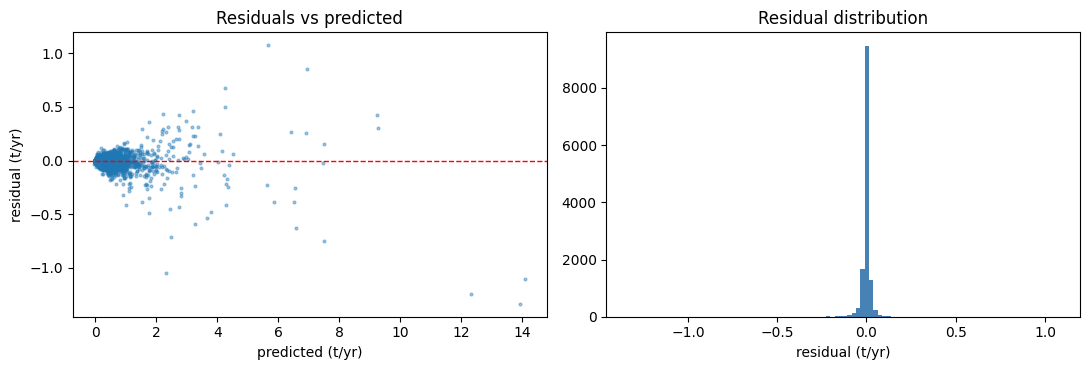

mean residual -0.00061 t/yr   |   90% of errors within +/- 0.0291 t/yr


In [11]:
resid = best_pred - y_test.values
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].scatter(best_pred, resid, s=4, alpha=0.4); ax[0].axhline(0, color="r", ls="--", lw=1)
ax[0].set_xlabel("predicted (t/yr)"); ax[0].set_ylabel("residual (t/yr)"); ax[0].set_title("Residuals vs predicted")
ax[1].hist(resid, bins=100, color="steelblue"); ax[1].set_xlabel("residual (t/yr)"); ax[1].set_title("Residual distribution")
plt.tight_layout(); plt.savefig("gbr_residuals.png", dpi=130); plt.show()
print(f"mean residual {resid.mean():+.5f} t/yr   |   90% of errors within +/- {np.percentile(np.abs(resid), 90):.4f} t/yr")

Feature importance — contribution to error reduction across all splits, sums to 1.

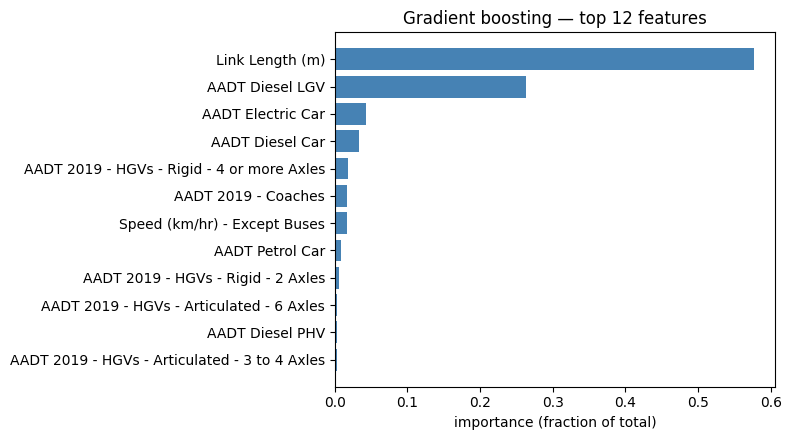

,0
Link Length (m),0.5768
AADT Diesel LGV,0.2633
AADT Electric Car,0.0425
AADT Diesel Car,0.0333
AADT 2019 - HGVs - Rigid - 4 or more Axles,0.0186
AADT 2019 - Coaches,0.0173
Speed (km/hr) - Except Buses,0.0161
AADT Petrol Car,0.0084
AADT 2019 - HGVs - Rigid - 2 Axles,0.0052
AADT 2019 - HGVs - Articulated - 6 Axles,0.0034


In [12]:
imp = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)
top = imp.head(12)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(top.index[::-1], top.values[::-1], color="steelblue")
ax.set_xlabel("importance (fraction of total)")
ax.set_title("Gradient boosting — top 12 features")
plt.tight_layout(); plt.savefig("gbr_feature_importance.png", dpi=130); plt.show()
top.round(4)

### Error by road class

In [13]:
err = pd.DataFrame({"road_class": df.loc[X_test.index, "Road Classification"].values,
                    "actual": y_test.values, "pred": best_pred})
err["abs_err"] = (err.pred - err.actual).abs()
by_class = (err.groupby("road_class")
              .agg(links=("actual", "size"), mean_actual=("actual", "mean"), MAE=("abs_err", "mean"))
              .sort_values("mean_actual", ascending=False))
by_class.round(4)

,links,mean_actual,MAE
road_class,,,
M11,5,3.9812,0.2589
M4,21,2.7684,0.1497
M25,17,1.9768,0.1392
M1,18,1.7526,0.1086
A Road,6793,0.2509,0.0178
B Road,1658,0.1209,0.0101
C / Unclassified Road,4881,0.0844,0.0090


## 10. Save results for the Task 4 comparison

In [14]:
res_df.to_csv("gbr_results.csv", index=False)
with open("gbr_best.json", "w") as f:
    json.dump({"model": best_label,
               "params": best_model.get_params(),
               "metrics": res_df[res_df.model == best_label].iloc[0].to_dict(),
               "top_features": imp.head(12).round(4).to_dict()},
              f, indent=2, default=str)
print("saved gbr_results.csv and gbr_best.json")
res_df

saved gbr_results.csv and gbr_best.json


,model,MAE,RMSE,R2,fit_s
0,Mean baseline,0.1867,0.4447,-0.0013,NaN
1,GBR default,0.0328,0.0723,0.9735,22.5
2,"GBR, log target",0.0236,0.0770,0.9699,24.3
3,GBR n=100 lr=0.1 d=3 sub=1.0,0.0328,0.0723,0.9735,19.9
4,GBR log n=100 lr=0.1 d=3 sub=1.0,0.0236,0.0770,0.9699,20.1
5,GBR n=200 lr=0.1 d=4 sub=0.8,0.0185,0.0501,0.9873,46.1
6,GBR log n=200 lr=0.1 d=4 sub=0.8,0.0142,0.0407,0.9916,44.8
7,GBR n=300 lr=0.05 d=5 sub=0.8,0.0149,0.0462,0.9892,83.5
8,GBR log n=300 lr=0.05 d=5 sub=0.8,0.0126,0.0427,0.9908,84.3
9,GBR n=500 lr=0.05 d=4 sub=0.8,0.0158,0.0446,0.9899,112.6


## 11. Findings

Gradient boosting reaches R² ~0.99 against ~0.58 for the linear models on the same data and split. NOx isn't a linear additive function of traffic counts, so the linear models can't capture the interaction between link length, vehicle mix and road type.

Link length is the strongest predictor, as expected. After that the weight sits on diesel LGVs and HGVs, well above petrol cars despite cars being far more numerous — NOx on London's major roads is disproportionately a diesel freight and light-goods problem. Note `AADT Electric Car` also carries some importance; electric vehicles emit no NOx, so it is acting as a proxy for newer, more central fleets rather than a causal driver.

Limitations: one year only; the target is LAEI's modelled inventory rather than roadside measurement, so the model reproduces the inventory's assumptions; major roads only; emissions rather than concentrations.